# Starter Notebook with Report Visuals  
## Applied AI Project — Multilingual News Summarization with mT5



## 1. Install dependencies

In [1]:
!pip -q uninstall -y datasets
!pip -q install "datasets==3.6.0" "transformers>=4.46,<5" evaluate sentencepiece accelerate rouge_score pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 150.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.9 MB/s eta 0:00:00


## 2. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
import evaluate

from transformers import (
    MT5ForConditionalGeneration,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

torch.backends.cuda.matmul.allow_tf32 = True


## 3. Configuration

In [3]:
MODEL_NAME = "google/mt5-small"
LANGUAGE = "es"   # valid MLSUM options: "de", "es", "fr", "ru"

MAX_INPUT_LEN = 512
MAX_TARGET_LEN = 64

TRAIN_SAMPLES = 2000
VAL_SAMPLES = 300
TEST_SAMPLES = 300

OUTPUT_DIR = f"./mt5_mlsum_{LANGUAGE}_starter_visuals"
PLOTS_DIR = os.path.join(OUTPUT_DIR, "report_plots")
TABLES_DIR = os.path.join(OUTPUT_DIR, "report_tables")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)


## 4. Load MLSUM dataset

In [4]:
from datasets import load_dataset

dataset = load_dataset("reciTAL/mlsum", LANGUAGE)
dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mlsum.py: 0.00B [00:00, ?B/s]

The repository for reciTAL/mlsum contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/reciTAL/mlsum.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/266367 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10358 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/13920 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 266367
    })
    validation: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 10358
    })
    test: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 13920
    })
})

## 5. Inspect an example

In [5]:
sample = dataset["train"][0]
print("Keys:", sample.keys())
print("\nArticle preview:\n", sample["text"][:1000])
print("\nSummary preview:\n", sample["summary"])

Keys: dict_keys(['text', 'summary', 'topic', 'url', 'title', 'date'])

Article preview:
 De momento, no podemos responder a la pregunta frivolona que toda España se hace hoy, además de por qué bebí tanto anoche. ¿Qué cadena ganó en la retransmisión de las campanadas? Los sentimos, Sofres no ofrece hoy los datos por ser festivo. Los contendientes fueron el colegueo de Los Manolos, Manu Carreño y Manolo Lama (Cuatro), la gracia y juventud de los actores Antonio Garrido y Patricia Montero (Antena 3), el morboso dúo Sálvame, Javier Vázquez y Belén Esteban (Telecinco), el valor seguro de Anne Igartiburu en TVE-1 y el humor inteligente de Berto y Ana Morgade (La Sexta). Por primera vez en 13 años, Ramón García, el entrañable Ramontxu que aguantaba el frío como nadie bajo su capa, no estaba ante las cámaras. El menú para las últimas que los españoles vieron en el sistema analógico -el próximo 3 de abril todas las emisiones pasan a la TDT-, era de lo más variadito. La clásica TVE encargó por q

## 6. Create small subsets for a Colab starter run

In [6]:
train_ds = dataset["train"].shuffle(seed=42).select(range(min(TRAIN_SAMPLES, len(dataset["train"]))))
val_ds = dataset["validation"].shuffle(seed=42).select(range(min(VAL_SAMPLES, len(dataset["validation"]))))
test_ds = dataset["test"].shuffle(seed=42).select(range(min(TEST_SAMPLES, len(dataset["test"]))))

print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
    num_rows: 2000
})
Dataset({
    features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
    num_rows: 300
})
Dataset({
    features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
    num_rows: 300
})


## 7. Dataset summary table for report

In [7]:
dataset_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples Used": [len(train_ds), len(val_ds), len(test_ds)]
})
dataset_summary

,Split,Samples Used
0,Train,2000
1,Validation,300
2,Test,300


In [8]:
dataset_summary.to_csv(os.path.join(TABLES_DIR, "dataset_summary.csv"), index=False)
print("Saved:", os.path.join(TABLES_DIR, "dataset_summary.csv"))

Saved: ./mt5_mlsum_es_starter_visuals/report_tables/dataset_summary.csv


## 8. Visualize source and target length distributions

In [9]:
def get_lengths(ds, text_col="text", summary_col="summary", max_rows=500):
    rows = min(max_rows, len(ds))
    article_lens = [len(ds[i][text_col].split()) for i in range(rows)]
    summary_lens = [len(ds[i][summary_col].split()) for i in range(rows)]
    return article_lens, summary_lens

article_lens, summary_lens = get_lengths(train_ds)

print("Average article length:", round(np.mean(article_lens), 2))
print("Average summary length:", round(np.mean(summary_lens), 2))

Average article length: 691.78
Average summary length: 19.41


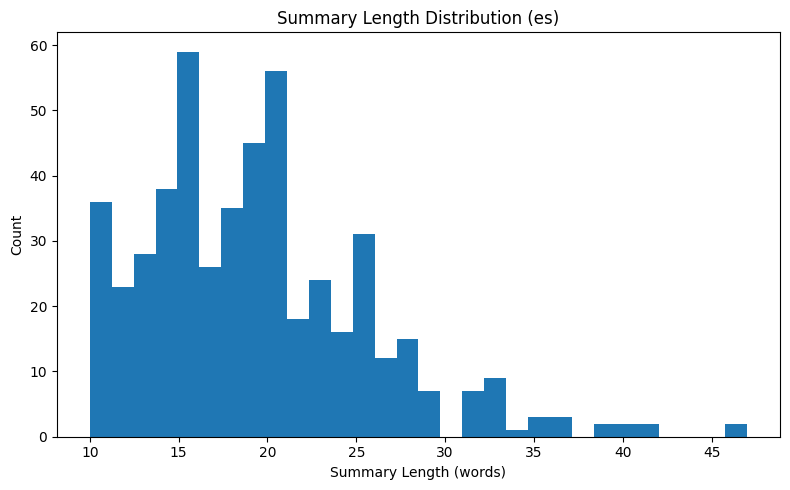

Saved: ./mt5_mlsum_es_starter_visuals/report_plots/summary_length_hist_es.png


In [10]:
plt.figure(figsize=(8, 5))
plt.hist(summary_lens, bins=30)
plt.xlabel("Summary Length (words)")
plt.ylabel("Count")
plt.title(f"Summary Length Distribution ({LANGUAGE})")
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, f"summary_length_hist_{LANGUAGE}.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

## 9. Load tokenizer and model

In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = MT5ForConditionalGeneration.from_pretrained(MODEL_NAME)


## 10. Preprocessing

In [15]:
prefix = "summarize: "

def preprocess_function(batch):
    inputs = [prefix + text for text in batch["text"]]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )

    labels = tokenizer(
        text_target=batch["summary"],
        max_length=MAX_TARGET_LEN,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


## 11. Tokenize datasets

In [16]:
tokenized_train = train_ds.map(preprocess_function, batched=True, remove_columns=train_ds.column_names)
tokenized_val = val_ds.map(preprocess_function, batched=True, remove_columns=val_ds.column_names)
tokenized_test = test_ds.map(preprocess_function, batched=True, remove_columns=test_ds.column_names)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

## 12. ROUGE metric

In [17]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.array(predictions)
    labels = np.array(labels)

    if predictions.ndim == 3:
        predictions = np.argmax(predictions, axis=-1)

    predictions = np.where(
        (predictions < 0) | (predictions >= tokenizer.vocab_size),
        tokenizer.pad_token_id,
        predictions
    )

    labels = np.where(labels == -100, tokenizer.pad_token_id, labels)
    labels = np.where(
        (labels < 0) | (labels >= tokenizer.vocab_size),
        tokenizer.pad_token_id,
        labels
    )

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() if pred.strip() else "empty" for pred in decoded_preds]
    decoded_labels = [label.strip() if label.strip() else "empty" for label in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    return {
        "rouge1": round(result["rouge1"], 4),
        "rouge2": round(result["rouge2"], 4),
        "rougeL": round(result["rougeL"], 4),
        "rougeLsum": round(result["rougeLsum"], 4),
    }


## 13. Data collator

In [18]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100
)


## 14. Training arguments

In [19]:
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=1,
    predict_with_generate=True,
    generation_max_length=64,
    fp16=False,
    bf16=torch.cuda.is_available(),
    optim="adafactor",
    logging_steps=25,
    report_to="none",
    logging_dir=os.path.join(OUTPUT_DIR, "logs"),
)


## 15. Trainer

In [20]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


/tmp/ipykernel_492/4048247955.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


## 16. Train

In [21]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Sample tokenized keys:", tokenized_train[0].keys())
print("First 20 input_ids:", tokenized_train[0]["input_ids"][:20])
print("First 20 labels:", tokenized_train[0]["labels"][:20])


CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
Tokenizer vocab size: 250100
Sample tokenized keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
First 20 input_ids: [196098, 10701, 267, 4295, 259, 31083, 358, 435, 281, 62140, 211978, 372, 362, 15736, 289, 52485, 269, 742, 75077, 269]
First 20 labels: [5254, 462, 10235, 362, 31789, 2287, 342, 108568, 268, 269, 573, 259, 34568, 259, 84444, 262, 1]


In [22]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,4.196800,2.828999,0.197800,0.050500,0.157600,0.157500


TrainOutput(global_step=1000, training_loss=5.3011425018310545, metrics={'train_runtime': 256.775, 'train_samples_per_second': 7.789, 'train_steps_per_second': 3.894, 'total_flos': 1054698660741120.0, 'train_loss': 5.3011425018310545, 'epoch': 1.0})

## 17. Evaluate on test set

In [23]:
test_results = trainer.evaluate(eval_dataset=tokenized_test, metric_key_prefix="test")
test_results

{'test_loss': 2.9373488426208496,
 'test_rouge1': 0.1946,
 'test_rouge2': 0.0458,
 'test_rougeL': 0.1556,
 'test_rougeLsum': 0.1558,
 'test_runtime': 78.6151,
 'test_samples_per_second': 3.816,
 'test_steps_per_second': 1.908,
 'epoch': 1.0}

## 18. Save a clean results table for the report

In [24]:
results_df = pd.DataFrame([{
    "Model": "mT5-small",
    "Language": LANGUAGE,
    "ROUGE-1": test_results.get("test_rouge1"),
    "ROUGE-2": test_results.get("test_rouge2"),
    "ROUGE-L": test_results.get("test_rougeL"),
    "ROUGE-Lsum": test_results.get("test_rougeLsum"),
}])

results_df

,Model,Language,ROUGE-1,ROUGE-2,ROUGE-L,ROUGE-Lsum
0,mT5-small,es,0.1946,0.0458,0.1556,0.1558


In [25]:
results_csv = os.path.join(TABLES_DIR, f"rouge_results_{LANGUAGE}.csv")
results_df.to_csv(results_csv, index=False)
print("Saved:", results_csv)

Saved: ./mt5_mlsum_es_starter_visuals/report_tables/rouge_results_es.csv


## 19. ROUGE bar chart for the report

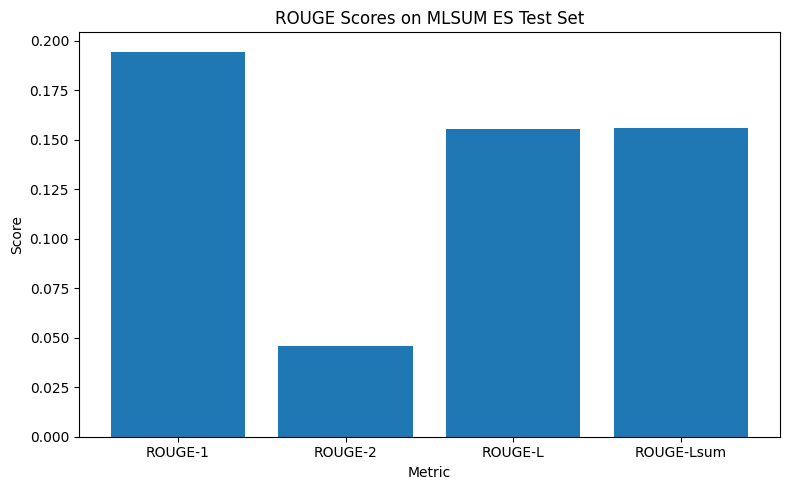

Saved: ./mt5_mlsum_es_starter_visuals/report_plots/rouge_bar_chart_es.png


,Metric,Score
0,ROUGE-1,0.1946
1,ROUGE-2,0.0458
2,ROUGE-L,0.1556
3,ROUGE-Lsum,0.1558


In [26]:
rouge_plot_df = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum"],
    "Score": [
        float(test_results.get("test_rouge1", 0)),
        float(test_results.get("test_rouge2", 0)),
        float(test_results.get("test_rougeL", 0)),
        float(test_results.get("test_rougeLsum", 0)),
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(rouge_plot_df["Metric"], rouge_plot_df["Score"])
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title(f"ROUGE Scores on MLSUM {LANGUAGE.upper()} Test Set")
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, f"rouge_bar_chart_{LANGUAGE}.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)
rouge_plot_df

## 20. Training and evaluation loss curves

In [27]:
log_history = trainer.state.log_history
logs_df = pd.DataFrame(log_history)
logs_df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,...,total_flos,train_loss,test_loss,test_rouge1,test_rouge2,test_rougeL,test_rougeLsum,test_runtime,test_samples_per_second,test_steps_per_second
0,20.3949,4813.746094,0.000098,0.025,25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.7545,1408.085938,0.000095,0.050,50,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8.8482,98.711029,0.000093,0.075,75,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.7394,368.382812,0.000090,0.100,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.4711,17.540209,0.000088,0.125,125,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
train_loss_df = logs_df[logs_df["loss"].notna()].copy() if "loss" in logs_df.columns else pd.DataFrame()
eval_loss_df = logs_df[logs_df["eval_loss"].notna()].copy() if "eval_loss" in logs_df.columns else pd.DataFrame()

print("Train loss rows:", len(train_loss_df))
print("Eval loss rows:", len(eval_loss_df))

Train loss rows: 40
Eval loss rows: 1


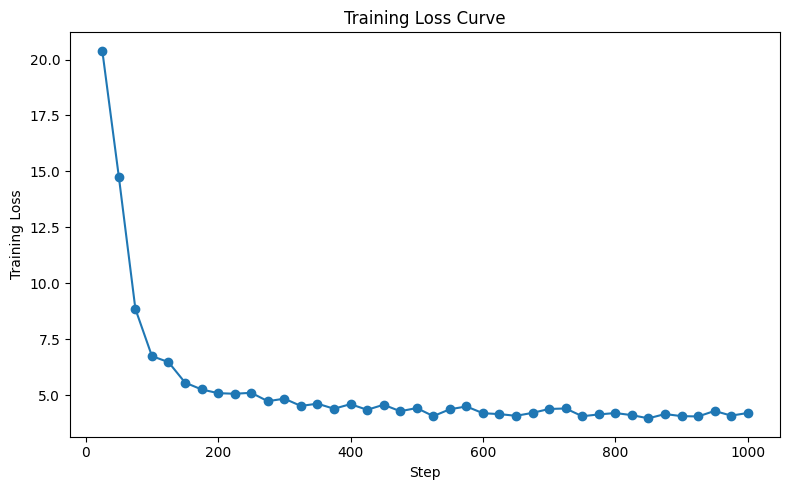

Saved: ./mt5_mlsum_es_starter_visuals/report_plots/training_loss_curve_es.png


In [29]:
if not train_loss_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o")
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.title("Training Loss Curve")
    plt.tight_layout()
    plot_path = os.path.join(PLOTS_DIR, f"training_loss_curve_{LANGUAGE}.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", plot_path)
else:
    print("No training loss logs found.")

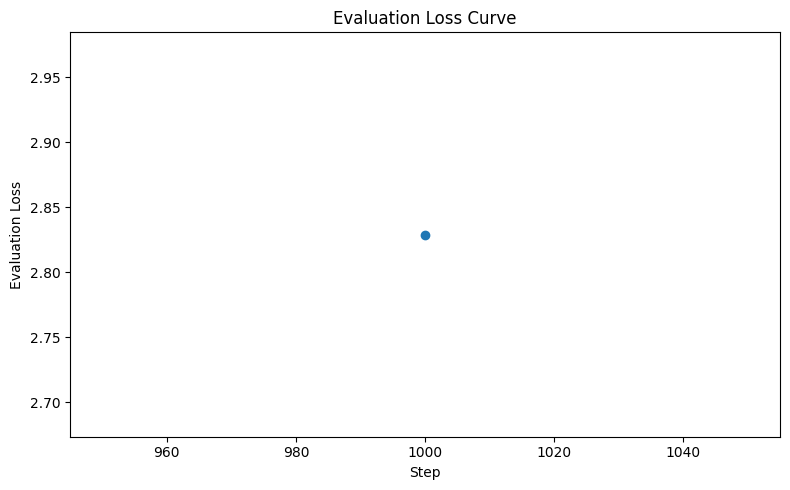

Saved: ./mt5_mlsum_es_starter_visuals/report_plots/eval_loss_curve_es.png


In [30]:
if not eval_loss_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], marker="o")
    plt.xlabel("Step")
    plt.ylabel("Evaluation Loss")
    plt.title("Evaluation Loss Curve")
    plt.tight_layout()
    plot_path = os.path.join(PLOTS_DIR, f"eval_loss_curve_{LANGUAGE}.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", plot_path)
else:
    print("No evaluation loss logs found.")

## 21. Generate summaries for qualitative examples

In [31]:
def generate_summary(text, max_new_tokens=64):
    device = model.device
    inputs = tokenizer(
        prefix + text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4
        )

    return tokenizer.decode(outputs[0].detach().cpu(), skip_special_tokens=True)


In [32]:
example_rows = []
num_examples = min(5, len(test_ds))

for i in range(num_examples):
    article = test_ds[i]["text"]
    gold_summary = test_ds[i]["summary"]
    pred_summary = generate_summary(article)

    example_rows.append({
        "Example": i + 1,
        "Article Snippet": article[:500].replace("\n", " "),
        "Gold Summary": gold_summary,
        "Predicted Summary": pred_summary
    })

examples_df = pd.DataFrame(example_rows)
examples_df

,Example,Article Snippet,Gold Summary,Predicted Summary
0,1,En los últimos años se han estrenado algunos d...,"En un sistema como el español, de investidura ...",El debate sobre la reforma del artículo 99 de ...
1,2,Un grupo de palestinos espera a cruzar a Egipt...,Decenas de miles de palestinos abandonan el en...,"El sociólogo Mohamed Ahmad, de 18 años, se ha ..."
2,3,"A partir del 26 de septiembre de 1519, las cin...",Un historiador militar descubre la procedencia...,La flota de Magallanes-Elcano intentará dar la...
3,4,El Mundial de Fútbol Femenino 2019 ha llegado ...,Estados Unidos gana la octava edición de la Co...,El Mundial de Fútbol Femenino 2019 ha llegado ...
4,5,"El primer secretario del PSC, Miquel Iceta, ha...",El primer secretario del PSC defiende en Madri...,La apuesta por el federalismo es “un camino qu...


In [33]:
examples_csv = os.path.join(TABLES_DIR, f"qualitative_examples_{LANGUAGE}.csv")
examples_df.to_csv(examples_csv, index=False)
print("Saved:", examples_csv)

Saved: ./mt5_mlsum_es_starter_visuals/report_tables/qualitative_examples_es.csv


## 22. Save model and tokenizer

In [34]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Saved model and tokenizer to: {OUTPUT_DIR}")

Saved model and tokenizer to: ./mt5_mlsum_es_starter_visuals
